<h1><span style="color:plum"><b>Connectivity of channels</h1>
<span style="color:darkmagenta">Theme: Work with connectivity ❀ Create mean ❀ Examine single pairs ❀ Compare time evolution</span>

<h2><span style="color:peachpuff"><b>One Pair: two electrodes</h2>
First I will plot two electrodes of correlation matrices over time. Next make function to recall them based on names, because there are 7750 of them. 
    
1) Load matrices in order
2) Extract one pair (i, j)
3) Store values
4) Plot

>Resolution is in 1 second overlap in 10 second windows, which I am gonna keep, since it's still information about connectivity.
>Keep that in mind in final <span style="color:darkmagenta">"Time(s)"</span> label of the plots...

<h2><span style="color:darkseagreen"><b>Connectivity information:</h2>

I've got connectivity (corelation matrices) for every 10 seconds of data. Which means I know how much are waves similar between two electrodes >> corelation. Hypothesis sounds like this: When brain is bored, the signal connectivity is supposed to go down.

<h3><span style="color:seagreen">Explanation</h3>
Whenever you calculate the correlation between any two electrodes you are measuring how similar those signals are. If areas interact usually their signal become more similar, even with a small time lag or a phase-locking. <b>Correlation</b> is just the simplest measure of this, but there are many other way to measure how signals depend on each other like the <i> Phase-Locking Value (PLV) or the Granger Causality (GC)</i>, we will use them only if the "simple" correlation shows no effect. 

So assuming that correlation is a good way to measure communication between different areas, the thing we are after is how this communication changes over time. So essentially if we calculate the correlation between two electrodes during the first 5 seconds and during the next 5 seconds if nothing changed between them we should have very similar values (there is always some noise). What Ali saw is that as you keep doing this (the next 5 seconds, the next 5 etc until the end) the correlations systematically go down, suggesting lower communication between brain areas. <b>So the hypothesis is that this lower communication indicates/explains/IS the boredom.</b>

<h3><span style="color:seagreen">Now about whether comparing the matrix or the single pair </h3>
The correlation matrix essentially has the correlation value for every pair of electrodes. It is likely that certain pairs of electrodes (certain index in the correlation matrix) change more over time than others. That is what I would expect, there is probably a certain subset of electrode pairs that change more, because those correspond to the brain areas that are most relevant for the boredom. We cannot see the insula in EEG (it's in the middle of the head), but should be able to see the cortical areas that are related to it. 

<b> If you take the average of the entire correlation matrix </b> then you are averaging away all the information about brain areas and looking at the communication in the whole brain. That is fine, seeing changes in the average of the matrix would mean that the changes in communication are widespread. But what can happen is that the average is close to the noise value (maybe some pairs are going up. some others are going down, so on average it stays the same). 

It is worthwhile looking at both things, single pairs (there are 124x123 of them per time point) and the whole average (just one number per time point). 

In [4]:
import os
import mne
import numpy as np
import warnings as w
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.signal import decimate
from elephant.signal_processing import butter

line = "\n❀----------------------------------------------------------❀\n"

<h3><span style="color:lightsteelblue"><b>Load matrices in order and store them into memory </h3>

way to store them: 3D >> np.stack()

><small> The numpy.stack() function is used to join multiple arrays by creating a new axis in the output array. This means the resulting array always has one extra dimension compared to the input arrays. To stack arrays, they must have the same shape, and NumPy places them along the axis you specify.

In [5]:
path = "./corr_matrices/"

files = sorted([f for f in os.listdir(path) if f.endswith("npy")])

matrices = []

for file in files:
    matrix = np.load(path + file)
    matrices.append(matrix)

connectivity = np.stack(matrices) # TIME, MATRIX
    

upper_indices = np.triu_indices(connectivity.shape[1], k=1) #ij above diagonal hoppefully

print (upper_indices) # really holds only ij numbmers
print (upper_indices[1])
print(len(matrices))
print (connectivity.shape)



(array([  0,   0,   0, ..., 122, 122, 123]), array([  1,   2,   3, ..., 123, 124, 124]))
[  1   2   3 ... 123 124 124]
591
(591, 125, 125)


<h3><span style="color:thistle"><b>Extract one pair (i, j) and store the value</h3>

In [6]:
i = 2
j = 9
values = []
for matrix in matrices:
    values.append(matrix[i, j])
#print(values)

<h3><span style="color:peachpuff"><b>Plot one connectivity - two electrodes</h3>

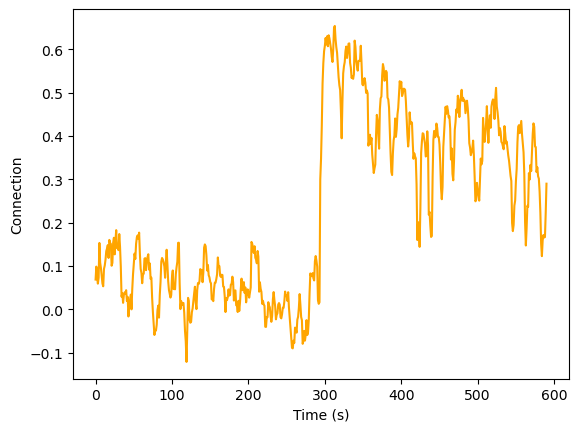

In [7]:
plt.plot(values, color='orange', label= "electrodes")
plt.xlabel('Time (s)')
plt.ylabel('Connection')
plt.show()

<h3><span style="color:rosybrown"><b>Loading data structure of montage</h3>

Just to be able later work between charackter electron names (Pz, Cp1...) and number nomenclature. 

In [8]:
#Loading data
path = "./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif"
with w.catch_warnings():
    w.simplefilter("ignore", RuntimeWarning)
    ica = mne.io.read_raw_fif(path, preload=False)
    
#Setting montage
ica.set_montage(mne.channels.make_standard_montage("standard_1005"))

ch_names = ica.info["ch_names"]
name_to_idx = {name: idx for idx, name in enumerate(ch_names)}

Opening raw data file ./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif...
    Range : 0 ... 4287999 =      0.000 ...   536.000 secs
Ready.
Opening raw data file /home/manka-roblik/AnalysisBooredEEG/Notebook/../data/C01/C01_2024-11-16_10-44-51_RS_before_ica-1.fif...
    Range : 4288000 ... 4807672 =    536.000 ...   600.959 secs
Ready.


<h2><span style="color:plum"><b>Plot and save all electrodes pair connectivity over time</h2>

Be avare of saving plots of over 7k pairs > takes around 10 minutes. Only asks about file existence, nor if you want them. 

In [9]:
pair_time_series = []
base_dir = "./Plots"
sub_dir = "ElectrodesPairConnectivity"
output_dir = os.path.join(base_dir, sub_dir)

if not os.path.exists(base_dir): #Pair
    os.mkdir(base_dir)
if os.path.exists(output_dir): #ElectrodePair...
    print("ElectrodesPairConnectivity folder already exists. Nothing created.")
else:
    os.mkdir(output_dir)
    print("Created ElectrodesPairConnectivity folder. Generating plots...")

    # Build pair time series
    pair_time_series = []

    for i, j in zip(*upper_indices):
        pair_time_series.append(connectivity[:, i, j])

    pair_time_series = np.array(pair_time_series)

    # Plot each pair
    for idx, electrode_pair in enumerate(pair_time_series):
        
        i = upper_indices[0][idx]
        j = upper_indices[1][idx]

        ch1 = ch_names[i]
        ch2 = ch_names[j]

        plt.figure()
        plt.plot(electrode_pair, color='orange')
        plt.title(f"{ch1} - {ch2}")
        plt.xlabel('Time (s)')
        plt.ylabel('Connection')

        filename = f"{ch1}_{ch2}.png"
        filepath = os.path.join(output_dir, filename)

        plt.savefig(filepath)
        plt.close()#For that ram love

ElectrodesPairConnectivity folder already exists. Nothing created.


<h2><span style="color:rosybrown"><b>Plot by names of electrodes:</h2>

Input names of electrodes or index of electrodes and print plots of their connectivity over time

F3 Pz


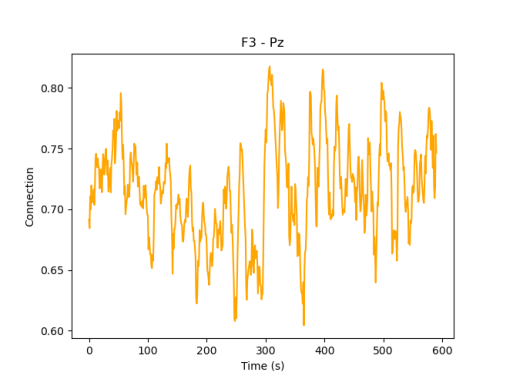

FC2 F7


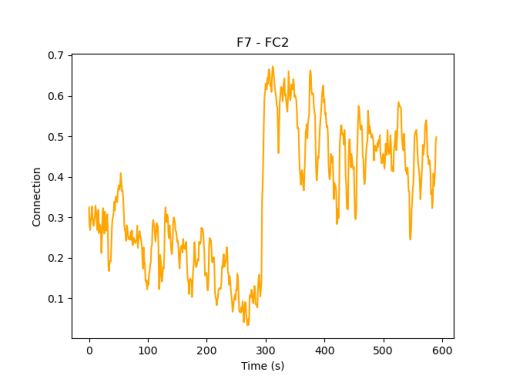

In [10]:
base_dir = "./Plots"
sub_dir = "ElectrodesPairConnectivity"
output_dir = os.path.join(base_dir, sub_dir)


def printPlot(ch1, ch2):
    
    # If integers were passed, convert to channel names
    if isinstance(ch1, int):
        ch1 = ch_names[ch1]
        
    if isinstance(ch2, int):
        ch2 = ch_names[ch2]

    print(ch1, ch2)
    file_name = f"{ch1}_{ch2}.png"
    file_path = os.path.join(output_dir, file_name)

    if not os.path.exists(file_path):
        file_name = f"{ch2}_{ch1}.png"
        file_path = os.path.join(output_dir, file_name)
        if not os.path.exists(file_path):
            print("Plot does not exist.")
            return

    img = mpimg.imread(file_path)

    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.show()

printPlot("F3", "Pz")

printPlot(10, 3)

<h2><span style="color:mediumslateblue"><b>Parcour of pattern findingᯓ★</h2>

Im gonna try create metrics which can be use for analysis: distinction. 

<span style="color:mediumslateblue"><b>Suggested improvement:

>    a) Mean connectivity over time
> 
>    b) Variability accross pairs over time
> 
>    c) Cluster dynamics
> 
>    d) Which pairs change the most

<span style="color:lightsteelblue"><b> What else can I try
- whole mean can flatten the outcome durring reorganisation, but mostly widespread effects
- I think it would be usefull to look at the most changing arear over time(faster with loosing the overlap)
- identify clusters in electrodes (they change in same like way in time,- meaning have kinda similar connectivity over time graphs)
- I can try indentify ways the signal goes
- I would love to pick on artifactis which are same for electrodes (like opening eye, etc)

<h3><span style="color:thistle"><b>a) To be or not to be mean over time</h3>

- for cycle over connectivity
- make means of every electrode pair
- plot it

Added mean over time and standard deviation over time

<span style="color:red"><b>TODO: </span>Vyplotit mean over time u ruznych subjektov, páry elektrod je spíš doplněnkk i ty segmanty. Hlavně zkusit ten cluster minimalně za týden 

Avarege global connectivity across the whole recording:  0.028331472089081777
how much global connectivity fluctuates over time:  0.009460980901264548


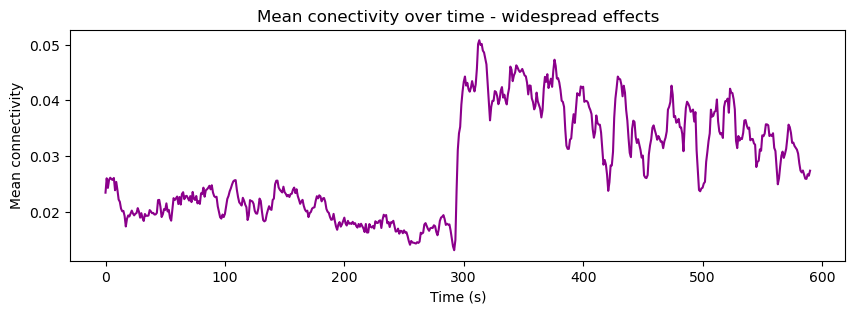

In [15]:
values = []
for matrix in connectivity:
    val = []
    for i, j in zip(*upper_indices):
        val.append(matrix[i][j])
    mean = np.mean(val)
    values.append(mean)

plt.figure(figsize=(10,3))
plt.plot(values, color='darkmagenta', label="Snipplet of 10s")
plt.title("Mean conectivity over time - widespread effects")
plt.xlabel('Time (s)')
plt.ylabel('Mean connectivity')

print("Avarege global connectivity across the whole recording: ", np.mean(values))
print("how much global connectivity fluctuates over time: ", np.std(values))

<h3><span style="color:thistle"><b>Comparing first and second half</h3>
<span style="color:red"><b>TODO: </span>Mean první s a druhý poloviny over time mean a pak i u ostatnich subjektu na porovnani otevrenzch oci a zavrenzch oci 

<h3><span style="color:khaki"><b>b) Variability over time</h3>
<span style="color:red"><b>TODO: </span>párz co maji největěi variabilita over time, std 
pak páry kde se absolutní hodnota mena nejvice mení :: minimum a maximum mean over time 

<h3><span style="color:darkseagreen"><b>c) Cluster dynamics</h3>
<span style="color:red"><b>TODO: </span>
systematickz vybitat oblasti podle Z stredu a ty vznecham a vezmu nalevo a napravo 
3d koordinaty channnelov popripadě liche a sude strany
F jako frontal a P jako pariental -> A, F : anterior 
interior, pariental a occipital vzadu ATD ATD 

leva prava, predni zadni, krizove, 

čim větší mean tím pa spolu komunikují 

<h3><span style="color:lightsteelblue"><b>d) Top 10 most changing pairs</h3>
<span style="color:red"><b>TODO: </span>Taky mohu